# VAE MNIST dengan Latent Space 2D

Versi notebook dari `vae_mnist.py`. Kode model, loss, dan fungsi visualisasi sama dengan script asal. Notebook memisahkan langkah kerja agar mudah dijalankan dan dijelaskan saat presentasi.


## 1. Import library


In [1]:
import csv
import json
import os
from pathlib import Path
import platform
import random
import time

ROOT = Path.cwd().resolve()
# Cache lokal dan backend non-interaktif membuat ekspor PNG aman di terminal.
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

from IPython.display import Image, display

print("Folder project:", ROOT)
print("PyTorch:", torch.__version__)


Folder project: /Users/tezamarlevifajar/Documents/Binus/generative-ai
PyTorch: 2.13.0


## 2. Konfigurasi

Latent dimension tetap **2**. Pemilihan device otomatis mengutamakan CUDA, kemudian MPS, lalu CPU. Untuk memakai model lama, ubah `EVALUATE_ONLY` menjadi `True`; konfigurasi training model lama akan dibaca dari checkpoint.


In [2]:
EPOCHS = 15
BATCH_SIZE = 128
LEARNING_RATE = 0.001
SEED = 42
DEVICE = "auto"  # Pilihan: auto, cuda, mps, cpu.
EVALUATE_ONLY = False
OUTPUT_DIR = ROOT / "outputs"
MODEL_PATH = ROOT / "models" / "vae_mnist.pth"

if EPOCHS < 1 or BATCH_SIZE < 1 or not np.isfinite(LEARNING_RATE) or LEARNING_RATE <= 0:
    raise ValueError("epochs, batch size, dan learning rate harus positif dan finite.")
def select_device(requested="auto"):
    cuda_available = torch.cuda.is_available()
    mps_available = torch.backends.mps.is_available()
    if requested == "auto":
        return torch.device("cuda" if cuda_available else "mps" if mps_available else "cpu")
    if requested == "cuda" and not cuda_available:
        raise RuntimeError("CUDA tidak tersedia. Gunakan --device auto atau cpu.")
    if requested == "mps" and not mps_available:
        raise RuntimeError("MPS tidak tersedia. Gunakan --device auto atau cpu.")
    return torch.device(requested)

device = select_device(DEVICE)
torch.set_num_threads(min(4, os.cpu_count() or 1))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
print("Device:", device)


Device: mps


## 3. Dataset MNIST

`ToTensor()` mengubah piksel menjadi float pada rentang 0 sampai 1. Dataset memakai 60.000 gambar training dan 10.000 gambar test. `download=True` mengunduh data jika belum tersedia. Label hanya membantu visualisasi, bukan training.


In [3]:
def load_data(batch_size, device, seed):
    # ToTensor mengubah uint8 [0,255] menjadi float [0,1], sesuai target BCE.
    transform = transforms.ToTensor()
    train_data = datasets.MNIST(ROOT / "data", train=True, download=True, transform=transform)
    test_data = datasets.MNIST(ROOT / "data", train=False, download=True, transform=transform)
    generator = torch.Generator().manual_seed(seed)
    options = dict(batch_size=batch_size, num_workers=0, pin_memory=device.type == "cuda")
    train_loader = DataLoader(train_data, shuffle=True, generator=generator, **options)
    test_loader = DataLoader(test_data, shuffle=False, **options)
    return train_loader, test_loader

train_loader, test_loader = load_data(BATCH_SIZE, device, SEED)
print("Jumlah training:", len(train_loader.dataset))
print("Jumlah test:", len(test_loader.dataset))


Jumlah training: 60000
Jumlah test: 10000


## 4. Model VAE

Alur: gambar 28 × 28 → Flatten → Linear 784 ke 400 → `mu` dan `log_var`, masing-masing 2 → reparameterization → decoder 2 ke 400 ke 784.

Sampling menggunakan `z = mu + exp(0.5 * log_var) * epsilon`, dengan `epsilon` dari normal standar. Decoder mengeluarkan logits saat training, sedangkan `decode()` mengembalikan gambar dengan sigmoid.


In [4]:
class VAE(nn.Module):
    """Encoder 784 -> 400 -> (mu, log_var); decoder 2 -> 400 -> 784."""

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(784, 400), nn.ReLU())
        self.mu = nn.Linear(400, 2)
        self.log_var = nn.Linear(400, 2)
        self.decoder = nn.Sequential(nn.Linear(2, 400), nn.ReLU(), nn.Linear(400, 784))

    def encode(self, images):
        hidden = self.encoder(images)
        return self.mu(hidden), self.log_var(hidden)

    @staticmethod
    def reparameterize(mu, log_var):
        # z = mu + sigma * epsilon. Noise terpisah agar gradient tetap mengalir.
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z):
        """Probabilitas intensitas piksel untuk visualisasi dan generasi."""
        return torch.sigmoid(self.decoder(z)).reshape(-1, 1, 28, 28)

    def forward(self, images):
        mu, log_var = self.encode(images)
        z = self.reparameterize(mu, log_var)
        # Raw logits dipakai oleh BCEWithLogits agar perhitungan lebih stabil.
        return self.decoder(z), mu, log_var

model = VAE().to(device)
print(model)
print("Jumlah parameter:", sum(parameter.numel() for parameter in model.parameters()))


VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=400, bias=True)
    (2): ReLU()
  )
  (mu): Linear(in_features=400, out_features=2, bias=True)
  (log_var): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
  )
)
Jumlah parameter: 631188


## 5. Reconstruction loss dan KL divergence

Total loss adalah **BCE + KL**. BCE membandingkan output dengan gambar input. KL mengatur posterior terhadap prior normal standar. Fungsi menjumlahkan komponen per gambar, lalu mengambil rata-rata batch; angka loss bukan accuracy.


In [5]:
def vae_loss(logits, images, mu, log_var):
    """Loss dijumlahkan atas piksel/dimensi latent, lalu dirata-rata per gambar."""
    # Reconstruction: mendorong decoder mempertahankan isi gambar input.
    reconstruction = F.binary_cross_entropy_with_logits(
        logits, images.flatten(start_dim=1), reduction="sum"
    ) / images.size(0)
    # KL(q(z|x) || N(0,I)): membuat posterior mendekati prior normal standar.
    kl = -0.5 * torch.sum(1 + log_var - mu.square() - log_var.exp()) / images.size(0)
    return reconstruction + kl, reconstruction, kl


## 6. Fungsi training dan evaluasi

Training memakai Adam dan satu sampel posterior per input. Evaluasi memakai test set tanpa pembaruan bobot. Loss per epoch menimbang batch terakhir sesuai jumlah gambarnya.


In [6]:
def train(model, loader, optimizer, device, epochs):
    history = []
    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        model.train()
        totals = torch.zeros(3, device=device)
        for images, _ in loader:  # Label digit tidak digunakan untuk training VAE.
            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits, mu, log_var = model(images)
            loss, reconstruction, kl = vae_loss(logits, images, mu, log_var)
            loss.backward()
            optimizer.step()
            totals += torch.stack((loss.detach(), reconstruction.detach(), kl.detach())) * len(images)
        averages = (totals / len(loader.dataset)).cpu().tolist()
        if not np.isfinite(averages).all():
            raise RuntimeError("Loss tidak finite. Periksa input dan learning rate.")
        row = dict(epoch=epoch, loss=averages[0], reconstruction=averages[1],
                   kl=averages[2], seconds=time.perf_counter() - start)
        history.append(row)
        print(f"Epoch {epoch}/{epochs} | Loss: {row['loss']:.4f} | "
              f"BCE: {row['reconstruction']:.4f} | KL: {row['kl']:.4f} | "
              f"Time: {row['seconds']:.1f}s", flush=True)
    return history

@torch.inference_mode()
def evaluate(model, loader, device):
    """Estimasi loss test dengan satu sampel posterior per gambar."""
    model.eval()
    totals = torch.zeros(3, device=device)
    for images, _ in loader:
        images = images.to(device)
        logits, mu, log_var = model(images)
        losses = vae_loss(logits, images, mu, log_var)
        totals += torch.stack(losses) * len(images)
    values = (totals / len(loader.dataset)).cpu().tolist()
    if not np.isfinite(values).all():
        raise RuntimeError("Loss evaluasi tidak finite.")
    return dict(zip(("loss", "reconstruction", "kl"), values))


## 7. Jalankan training atau muat checkpoint

Cell ini menjalankan training ketika `EVALUATE_ONLY = False`, lalu menyimpan bobot di CPU agar checkpoint dapat dimuat pada device lain. Mode evaluasi membaca bobot, konfigurasi, dan history dari checkpoint.


In [7]:
if EVALUATE_ONLY:
    checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    history, config = checkpoint["history"], checkpoint["config"]
else:
    config = dict(epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                  seed=SEED, latent_dim=2, hidden_dim=400, optimizer="Adam", kl_weight=1,
                  device=str(device), train_samples=len(train_loader.dataset),
                  test_samples=len(test_loader.dataset), python=platform.python_version(),
                  torch=str(torch.__version__), torchvision=str(torchvision.__version__),
                  matplotlib=matplotlib.__version__, numpy=np.__version__)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = train(model, train_loader, optimizer, device, EPOCHS)
    # State dict di CPU dapat dimuat ulang pada CUDA, MPS, maupun CPU.
    torch.save({"model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                "config": config, "history": history}, MODEL_PATH)

print(f"Final training loss: {history[-1]['loss']:.4f}")


Epoch 1/15 | Loss: 190.5184 | BCE: 184.7895 | KL: 5.7289 | Time: 3.7s
Epoch 2/15 | Loss: 168.1154 | BCE: 163.0893 | KL: 5.0260 | Time: 2.3s
Epoch 3/15 | Loss: 163.2832 | BCE: 158.0585 | KL: 5.2247 | Time: 2.5s
Epoch 4/15 | Loss: 160.1565 | BCE: 154.7256 | KL: 5.4310 | Time: 2.3s
Epoch 5/15 | Loss: 158.1104 | BCE: 152.5316 | KL: 5.5787 | Time: 2.3s
Epoch 6/15 | Loss: 156.6157 | BCE: 150.9198 | KL: 5.6959 | Time: 2.3s
Epoch 7/15 | Loss: 155.3786 | BCE: 149.6019 | KL: 5.7766 | Time: 2.5s
Epoch 8/15 | Loss: 154.3943 | BCE: 148.5535 | KL: 5.8409 | Time: 2.5s
Epoch 9/15 | Loss: 153.6118 | BCE: 147.7166 | KL: 5.8952 | Time: 2.4s
Epoch 10/15 | Loss: 152.8801 | BCE: 146.9365 | KL: 5.9435 | Time: 2.3s
Epoch 11/15 | Loss: 152.2189 | BCE: 146.2271 | KL: 5.9917 | Time: 2.3s
Epoch 12/15 | Loss: 151.5821 | BCE: 145.5571 | KL: 6.0249 | Time: 2.4s
Epoch 13/15 | Loss: 151.0814 | BCE: 145.0353 | KL: 6.0460 | Time: 2.5s
Epoch 14/15 | Loss: 150.6284 | BCE: 144.5443 | KL: 6.0841 | Time: 3.2s
Epoch 15/15 | L

## 8. Evaluasi pada test set

Seed evaluasi mengikuti seed training ditambah 1. Nilainya adalah rata-rata loss per gambar dengan satu sampel latent, bukan skor klasifikasi digit.


In [8]:
torch.manual_seed(config["seed"] + 1)
test_metrics = evaluate(model, test_loader, device)
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Reconstruction: {test_metrics['reconstruction']:.4f}")
print(f"KL divergence: {test_metrics['kl']:.4f}")


Test loss: 150.6803
Reconstruction: 144.5591
KL divergence: 6.1212


## 9. Reconstruction

Baris atas berisi original dan baris bawah reconstruction. Contoh pertama setiap digit dalam test set menjadi input. Decoder memakai `z = mu` agar perbandingan stabil.


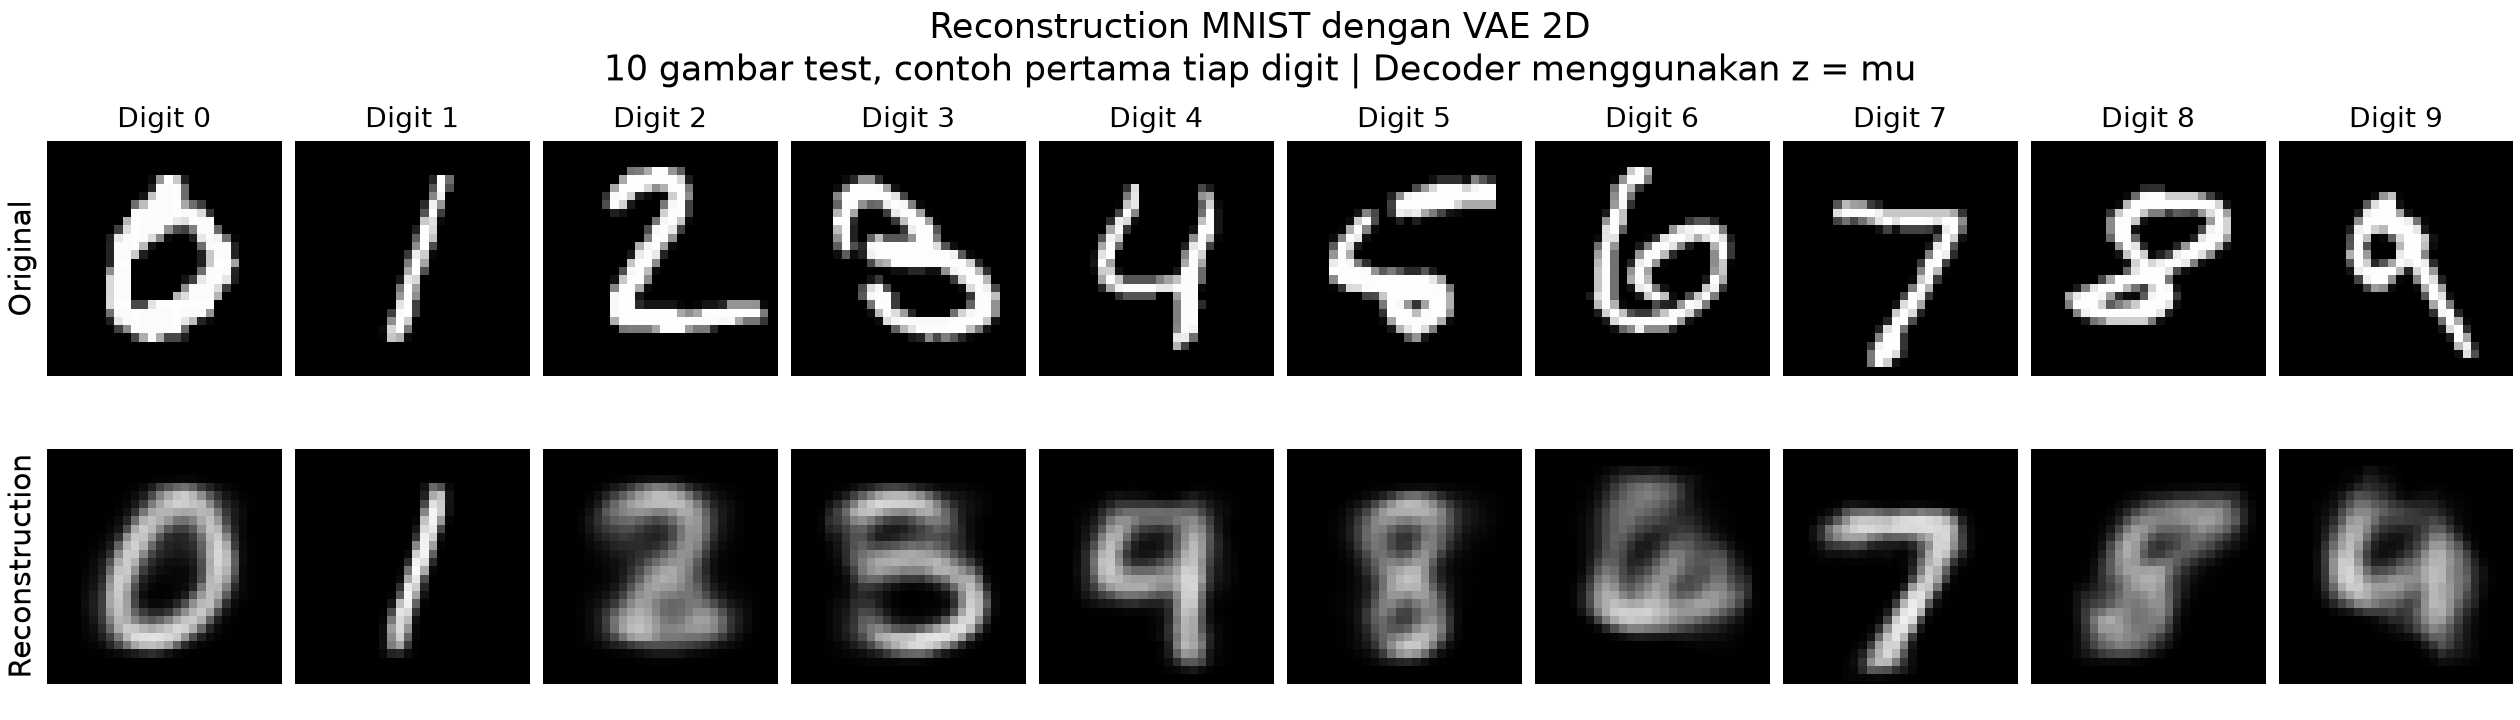

In [9]:
@torch.inference_mode()
def test_reconstruction(model, dataset, device, output_dir):
    """Perbandingan 2x10, satu contoh pertama setiap digit; skala piksel [0,1]."""
    model.eval()
    indices = [int((dataset.targets == digit).nonzero()[0]) for digit in range(10)]
    originals = torch.stack([dataset[index][0] for index in indices])
    mu, _ = model.encode(originals.to(device))
    reconstructed = model.decode(mu).cpu()  # Gunakan mean posterior agar stabil.
    fig, axes = plt.subplots(2, 10, figsize=(14, 4), layout="constrained")
    for column in range(10):
        for row, batch in enumerate((originals, reconstructed)):
            axes[row, column].imshow(batch[column, 0], cmap="gray", vmin=0, vmax=1)
            axes[row, column].set_xticks([])
            axes[row, column].set_yticks([])
        axes[0, column].set_title(f"Digit {column}", fontsize=11)
    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstruction", fontsize=12)
    fig.suptitle("Reconstruction MNIST dengan VAE 2D\n"
                 "10 gambar test, contoh pertama tiap digit | Decoder menggunakan z = mu", fontsize=14)
    fig.savefig(output_dir / "reconstruction.png", dpi=180)
    plt.close(fig)
    return indices

indices = test_reconstruction(model, test_loader.dataset, device, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / "reconstruction.png")))


## 10. Latent space 2D

Scatter memakai mean posterior seluruh 10.000 gambar test. Warna menunjukkan label. z1 dan z2 tidak mempunyai arti visual spesifik yang sudah terbukti.


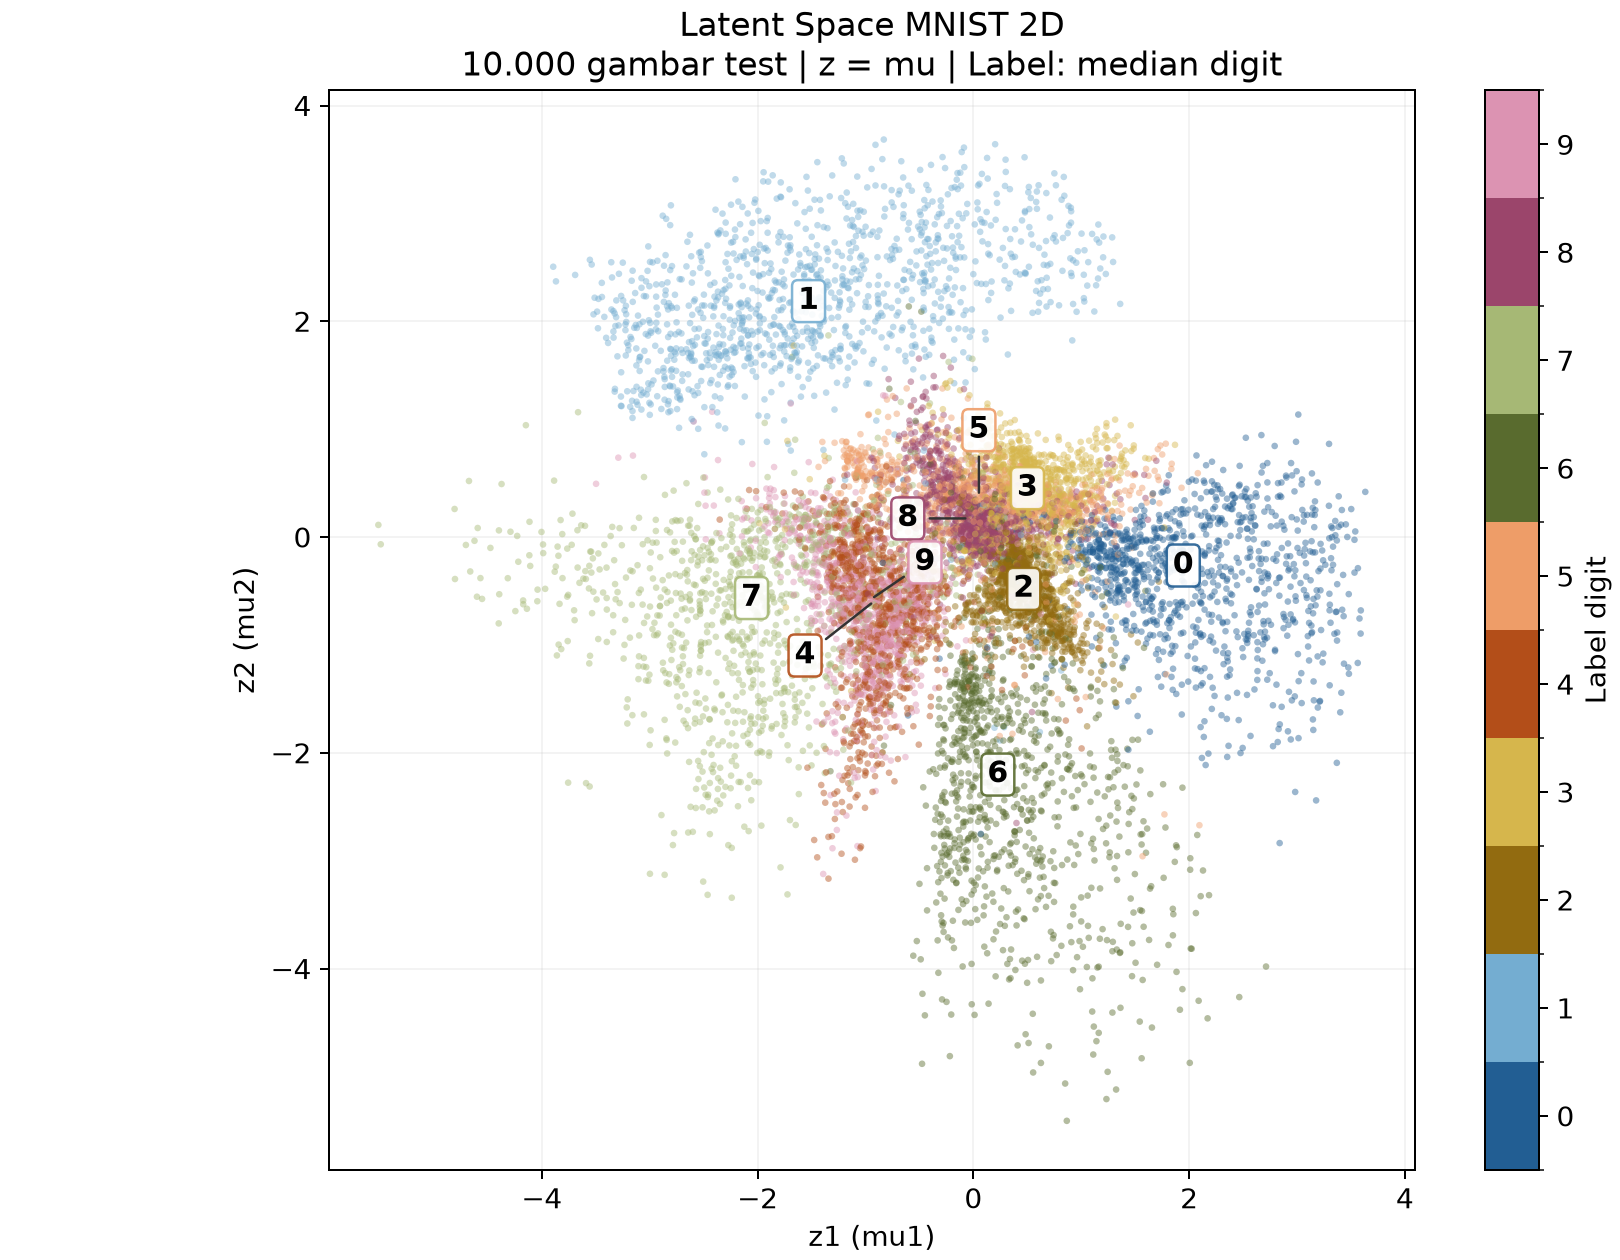

In [10]:
@torch.inference_mode()
def visualize_latent_space(model, loader, device, output_dir):
    """Scatter semua gambar test, satu titik per gambar, koordinat mean posterior."""
    model.eval()
    means, labels = [], []
    for images, digits in loader:
        mu, _ = model.encode(images.to(device))
        means.append(mu.cpu())
        labels.append(digits)
    points = torch.cat(means).numpy()
    digits = torch.cat(labels).numpy()
    np.savez_compressed(output_dir / "latent_points.npz", mu=points, labels=digits)
    # Lima keluarga warna, masing-masing dua tone; angka median membantu identifikasi.
    colors = ["#225E93", "#74ADD1", "#926B10", "#D6B64C", "#B34E19",
              "#EE9D68", "#596B2E", "#A6B875", "#9B456B", "#DC93B2"]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)
    fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
    # Acak urutan gambar agar digit tertentu tidak selalu menutupi kelas lainnya.
    order = np.random.default_rng(42).permutation(len(points))
    ax.scatter(points[order, 0], points[order, 1], c=digits[order], cmap=cmap,
               norm=norm, s=7, alpha=0.45, linewidths=0)
    label_offsets = {4: (-28, -22), 9: (22, 15), 5: (0, 27), 8: (-25, 0)}
    for digit in range(10):
        center = np.median(points[digits == digit], axis=0)
        offset = label_offsets.get(digit, (0, 0))
        ax.annotate(str(digit), xy=center, xytext=offset, textcoords="offset points",
                    ha="center", va="center", fontsize=12, fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color="#333333") if offset != (0, 0) else None,
                    bbox=dict(facecolor="white", edgecolor=colors[digit],
                              boxstyle="round,pad=0.2", alpha=0.9))
    fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                 ticks=range(10), label="Label digit")
    sample_count = f"{len(points):,}".replace(",", ".")
    ax.set(title=f"Latent Space MNIST 2D\n{sample_count} gambar test | z = mu | Label: median digit",
           xlabel="z1 (mu1)", ylabel="z2 (mu2)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15)
    ax.set_axisbelow(True)
    fig.savefig(output_dir / "latent_space.png", dpi=180)
    plt.close(fig)

visualize_latent_space(model, test_loader, device, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / "latent_space.png")))


## 11. Grid sampling 10 × 10

Decoder menerima 100 pasangan koordinat pada rentang [-2, 2]. Grid teratur ini membantu membaca perubahan bentuk, bukan sampel acak dengan densitas normal standar.


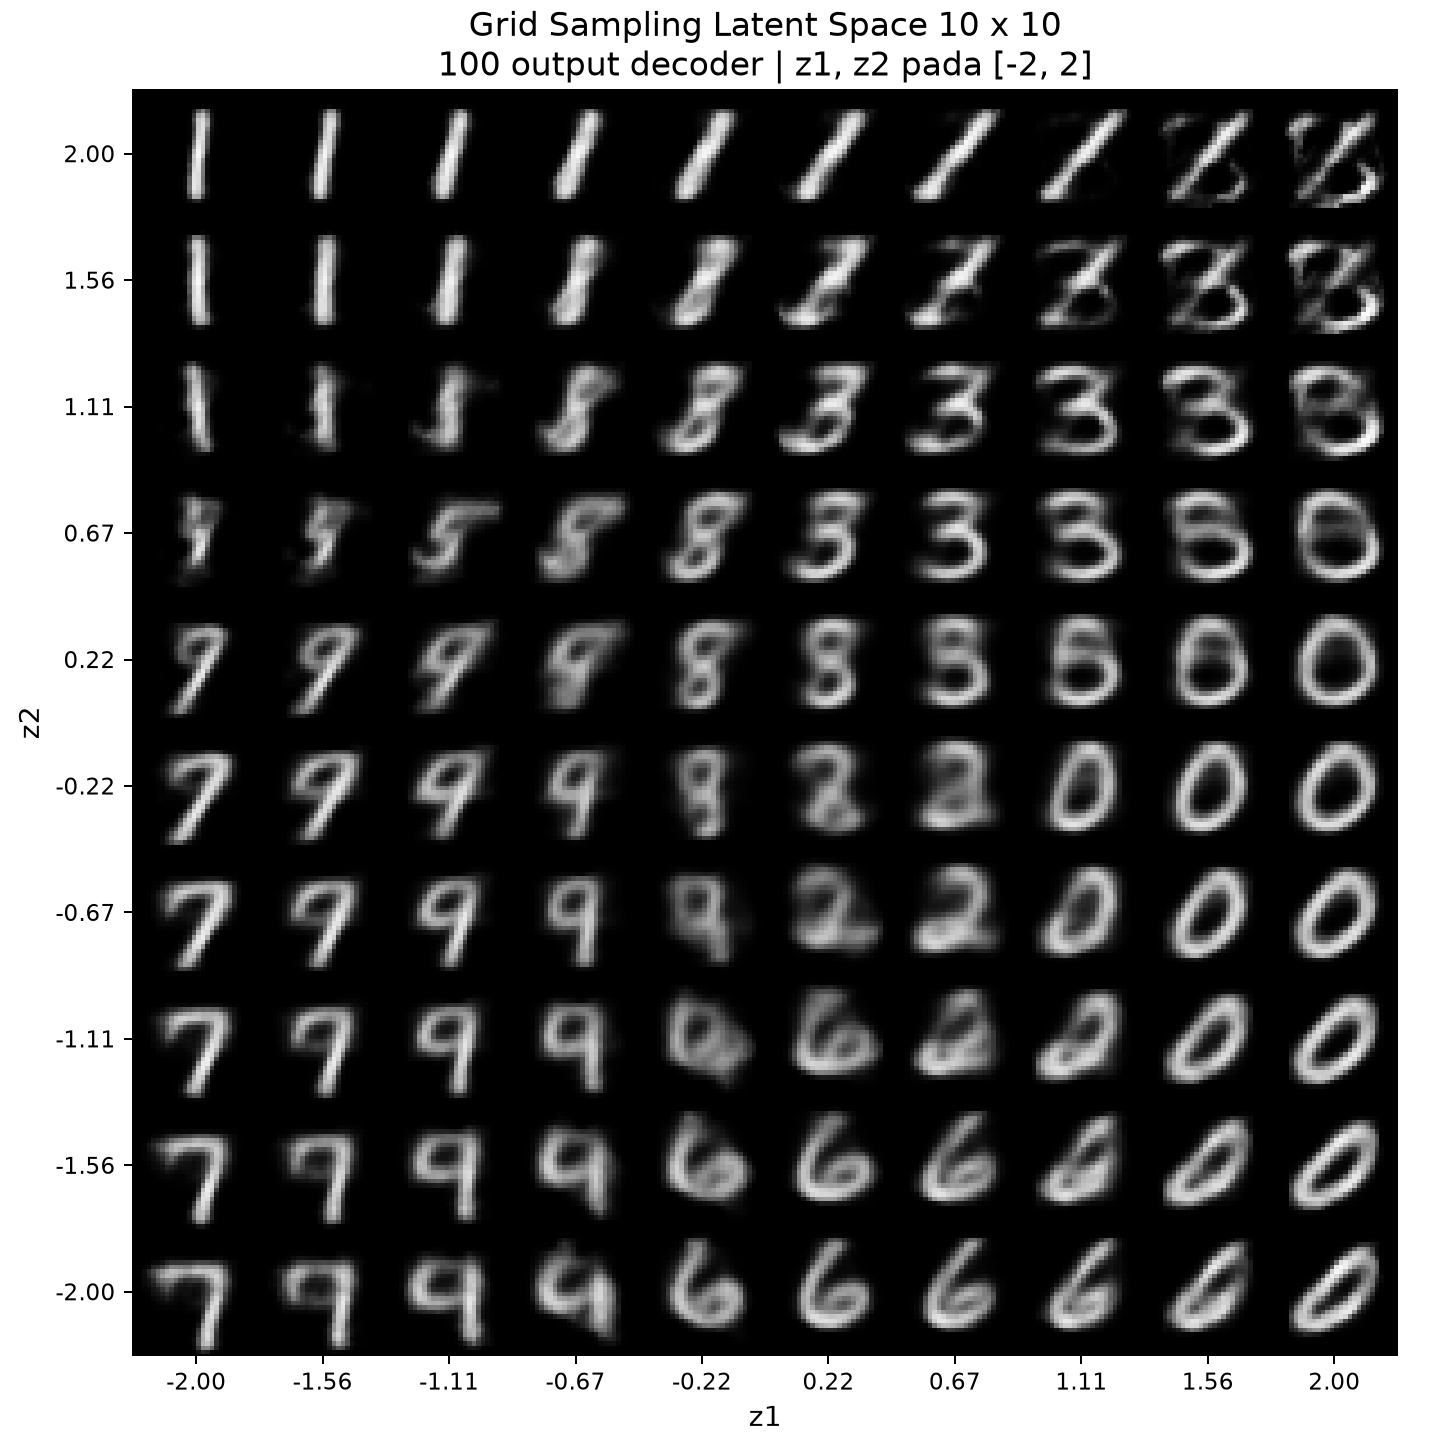

In [11]:
@torch.inference_mode()
def generate_latent_grid(model, device, output_dir):
    """Grid teratur 10x10 pada [-2,2], dengan z2 naik ke arah atas."""
    model.eval()
    coordinates = np.linspace(-2, 2, 10)
    z = torch.tensor([(x, y) for y in coordinates[::-1] for x in coordinates],
                     dtype=torch.float32, device=device)
    images = model.decode(z).cpu().numpy()[:, 0]
    canvas = images.reshape(10, 10, 28, 28).transpose(0, 2, 1, 3).reshape(280, 280)
    fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
    ax.imshow(canvas, cmap="gray", vmin=0, vmax=1)
    centers = np.arange(10) * 28 + 13.5
    ax.set_xticks(centers, [f"{x:.2f}" for x in coordinates], fontsize=9)
    ax.set_yticks(centers, [f"{y:.2f}" for y in coordinates[::-1]], fontsize=9)
    ax.set(title="Grid Sampling Latent Space 10 x 10\n100 output decoder | z1, z2 pada [-2, 2]",
           xlabel="z1", ylabel="z2")
    fig.savefig(output_dir / "latent_grid.png", dpi=180)
    plt.close(fig)

generate_latent_grid(model, device, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / "latent_grid.png")))


## 12. Kurva training loss

Panel kiri membandingkan total dan reconstruction loss. Panel kanan memakai skala terpisah untuk KL. Kurva berasal dari history training atau history checkpoint yang dimuat.


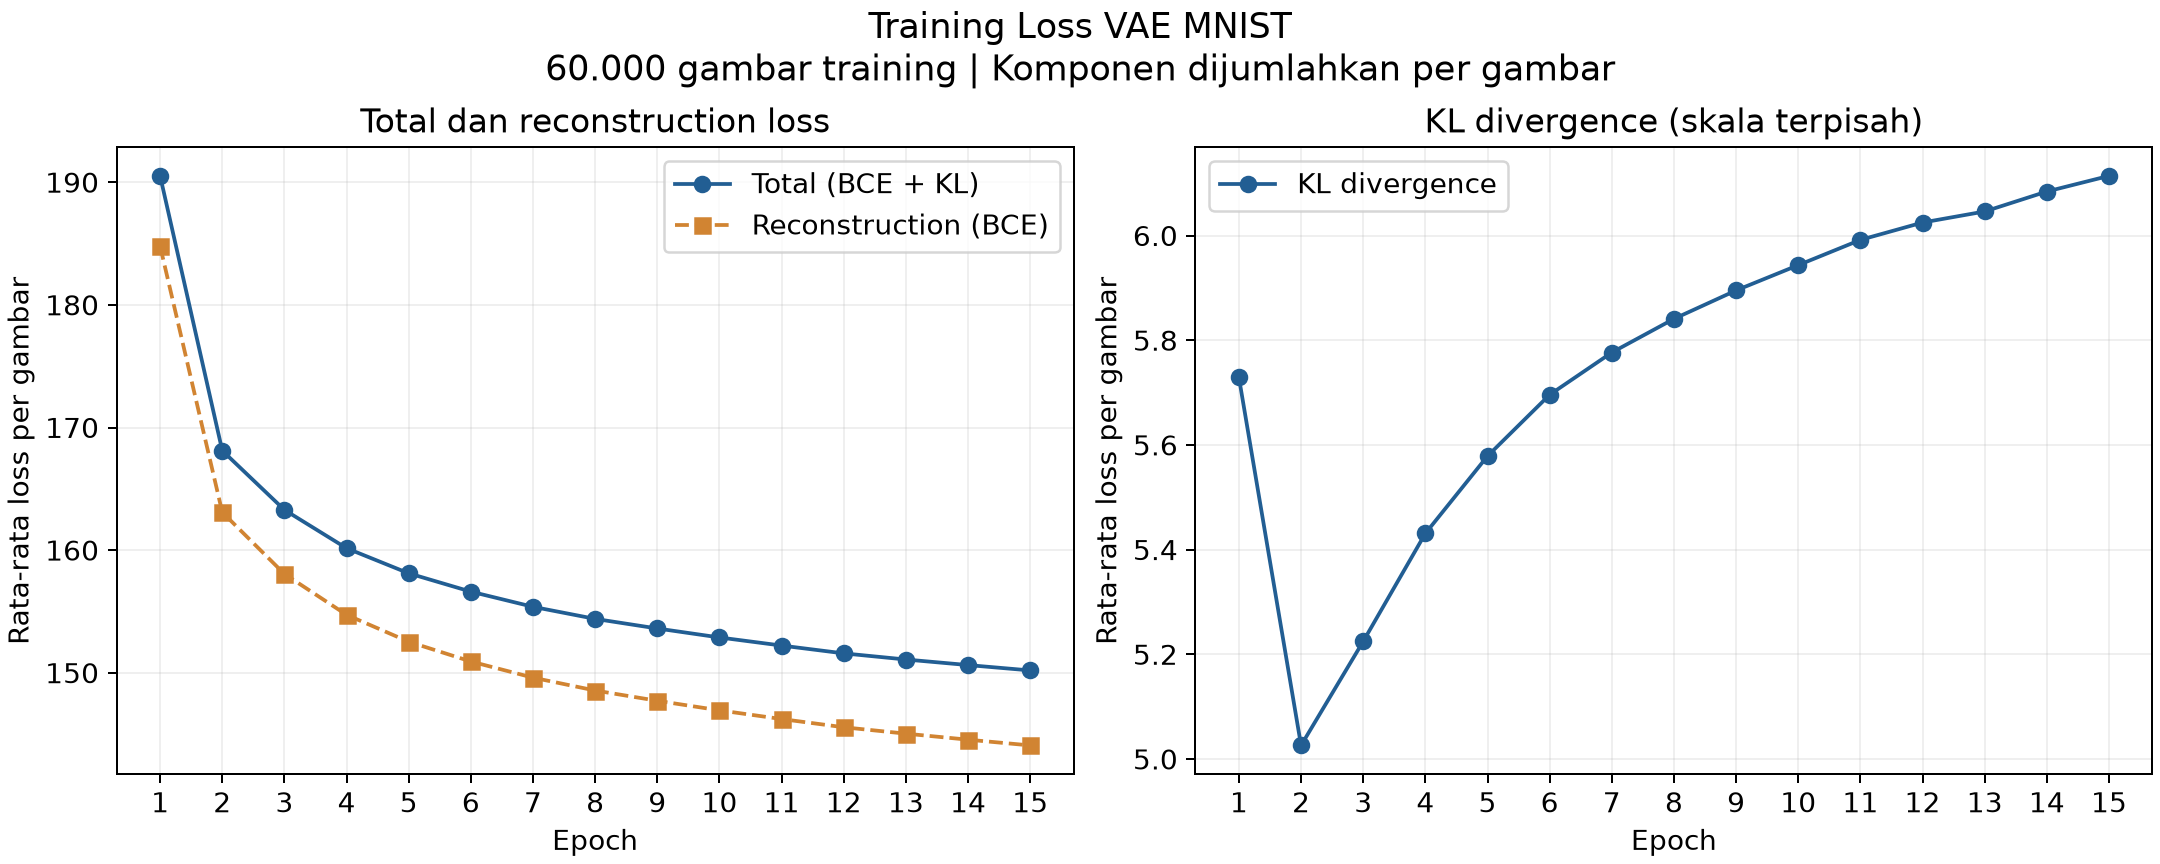

In [12]:
def plot_training_loss(history, output_dir):
    """Trend per epoch; semua loss adalah jumlah komponen per gambar, bukan per piksel."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
    epochs = [row["epoch"] for row in history]
    axes[0].plot(epochs, [row["loss"] for row in history], "o-", color="#225E93", label="Total (BCE + KL)")
    axes[0].plot(epochs, [row["reconstruction"] for row in history], "s--", color="#D18432", label="Reconstruction (BCE)")
    axes[1].plot(epochs, [row["kl"] for row in history], "o-", color="#225E93", label="KL divergence")
    for ax in axes:
        ax.set(xlabel="Epoch", ylabel="Rata-rata loss per gambar")
        ax.set_xticks(epochs)
        ax.grid(alpha=0.2)
        ax.legend()
    axes[0].set_title("Total dan reconstruction loss")
    axes[1].set_title("KL divergence (skala terpisah)")
    fig.suptitle("Training Loss VAE MNIST\n60.000 gambar training | Komponen dijumlahkan per gambar", fontsize=14)
    fig.savefig(output_dir / "training_loss.png", dpi=180)
    plt.close(fig)

plot_training_loss(history, OUTPUT_DIR)
display(Image(filename=str(OUTPUT_DIR / "training_loss.png")))


## 13. Saving Metrics

Selain PNG, notebook menyimpan history per epoch, konfigurasi training, dan metrik test. Scatter juga menyimpan koordinat mean serta label dalam `latent_points.npz`.


In [13]:
with (OUTPUT_DIR / "training_history.csv").open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(history[0]))
    writer.writeheader()
    writer.writerows(history)
summary = dict(config=config, final_train=history[-1], test=test_metrics,
               evaluation_device=str(device), reconstruction_test_indices=indices,
               parameter_count=sum(p.numel() for p in model.parameters()),
               training_seconds=sum(row["seconds"] for row in history))
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(summary, indent=2) + "\n")
print(f"Test loss: {test_metrics['loss']:.4f} | BCE: {test_metrics['reconstruction']:.4f} | "
      f"KL: {test_metrics['kl']:.4f}", flush=True)
print(f"Model: {MODEL_PATH}\nVisualisasi dan metrik: {OUTPUT_DIR.resolve()}", flush=True)


for filename in ("reconstruction.png", "latent_space.png", "latent_grid.png", "training_loss.png"):
    path = OUTPUT_DIR / filename
    assert path.is_file() and path.stat().st_size > 0, f"Output belum tersedia: {path}"
assert MODEL_PATH.is_file() and MODEL_PATH.stat().st_size > 0
print("Checkpoint dan empat PNG tersedia.")


Test loss: 150.6803 | BCE: 144.5591 | KL: 6.1212
Model: /Users/tezamarlevifajar/Documents/Binus/generative-ai/models/vae_mnist.pth
Visualisasi dan metrik: /Users/tezamarlevifajar/Documents/Binus/generative-ai/outputs
Checkpoint dan empat PNG tersedia.
